VQR and PQC method/ architecture 2

In [6]:
pip install pennylane pennylane-lightning pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [18]:
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

In [8]:
df_train = pd.read_csv('train_angle_encoded.csv')
df_test = pd.read_csv('test_angle_encoded.csv')

# Let's assume you select 2 features to map to 2 qubits
feature_columns = ['blue_angle', 'green_angle', 'log_blue_angle', 'log_green_angle', 'bg_ratio_angle', 'stumpf_angle']
target_column = 'depth'

In [9]:
# Extract arrays
X_train_raw = df_train[feature_columns].values
y_train_raw = df_train[target_column].values

X_test_raw = df_test[feature_columns].values
y_test_raw = df_test[target_column].values

In [10]:
# Convert to PennyLane tensors (Crucial: set requires_grad=False for static data)
X_train = np.array(X_train_raw, requires_grad=False)
y_train = np.array(y_train_raw, requires_grad=False)

X_test = np.array(X_test_raw, requires_grad=False)
y_test = np.array(y_test_raw, requires_grad=False)

In [11]:
# Validate structural shapes
num_qubits = X_train.shape[1]  # Confirms exactly 6 features
ansatz_layers = 3              # Circuit depth (increase if system underfits)

print(f"Configuring VQR Pipeline for a {num_qubits}-Qubit system...")

# Initialize lightning.qubit for optimized state vector simulation
dev = qml.device("lightning.qubit", wires=num_qubits)

Configuring VQR Pipeline for a 6-Qubit system...


In [12]:
@qml.qnode(dev)
def parameterized_regression_circuit(encoded_features, weights):
    """
    encoded_features: Array of size (6,) representing 1 data sample row.
    weights: Trainable matrix of shape (ansatz_layers, 6, 2)
    """
    # Step A: Data Injection Layer
    # Direct angle embedding across all 6 distinct wires
    for i in range(num_qubits):
        qml.RX(encoded_features[i], wires=i)
        
    # Step B: Variational Ansatz Layers
    for layer in range(ansatz_layers):
        # 1. Parameterized local operations
        for i in range(num_qubits):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
            
        # 2. Circular Entanglement Ring Topology
        # Connects qubit 0->1, 1->2, 2->3, 3->4, 4->5, and closes 5->0
        for i in range(num_qubits):
            qml.CNOT(wires=[i, (i + 1) % num_qubits])

    # Step C: Expectation Measurement
    return qml.expval(qml.PauliZ(0))


In [13]:
def cost_function(weights, bias, X_data, y_true):
    predictions = np.array([parameterized_regression_circuit(x, weights) for x in X_data])
    predictions = predictions + bias
    return np.mean((predictions - y_true) ** 2)

In [14]:
# Weight Init: Array matching (Layers, 6 Qubits, 2 Angles per Qubit)
np.random.seed(42)
initial_weights = 0.05 * np.random.randn(ansatz_layers, num_qubits, 2, requires_grad=True)
initial_bias = np.array(0.0, requires_grad=True)


In [15]:
opt = qml.AdamOptimizer(stepsize=0.3)
weights = initial_weights
bias = initial_bias
loss_history = []

epochs = 50
print("Running training loop across the 6-feature dataset...")

for epoch in range(epochs):
    (weights, bias), loss = opt.step_and_cost(cost_function, weights, bias, X_data=X_train, y_true=y_train)
    loss_history.append(loss)
    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Training MSE Loss: {loss:.5f}")


Running training loop across the 6-feature dataset...
Epoch 01/50 | Training MSE Loss: 264.37262
Epoch 02/50 | Training MSE Loss: 255.71668
Epoch 04/50 | Training MSE Loss: 232.12966
Epoch 06/50 | Training MSE Loss: 212.82347
Epoch 08/50 | Training MSE Loss: 195.62006
Epoch 10/50 | Training MSE Loss: 183.24354
Epoch 12/50 | Training MSE Loss: 171.65824
Epoch 14/50 | Training MSE Loss: 160.24167
Epoch 16/50 | Training MSE Loss: 150.09413
Epoch 18/50 | Training MSE Loss: 139.97302
Epoch 20/50 | Training MSE Loss: 131.22033
Epoch 22/50 | Training MSE Loss: 123.80566
Epoch 24/50 | Training MSE Loss: 116.94020
Epoch 26/50 | Training MSE Loss: 110.66264
Epoch 28/50 | Training MSE Loss: 105.13540
Epoch 30/50 | Training MSE Loss: 100.21144
Epoch 32/50 | Training MSE Loss: 95.91593
Epoch 34/50 | Training MSE Loss: 92.14190
Epoch 36/50 | Training MSE Loss: 88.88463
Epoch 38/50 | Training MSE Loss: 86.17074
Epoch 40/50 | Training MSE Loss: 83.84312
Epoch 42/50 | Training MSE Loss: 81.79789
Epoch 

In [16]:
# ==========================================
# 5. OUT-OF-SAMPLE EVALUATION (TEST FILE)
# ==========================================
print("\nEvaluating trained model against the Test File...")
test_predictions = np.array([parameterized_regression_circuit(x, weights) for x in X_test]) + bias
test_loss = np.mean((test_predictions - y_test) ** 2)

print(f"Final Out-of-Sample Test MSE: {test_loss:.5f}")



Evaluating trained model against the Test File...
Final Out-of-Sample Test MSE: 76.32457


In [21]:
mae  = mean_absolute_error(y_test, test_predictions)
rmse = root_mean_squared_error(y_test, test_predictions)
r2   = r2_score(y_test, test_predictions)

# 3. Print the diagnostic output
print("\n-------------------------- Results --------------------------")
print(f"Mean Absolute Error (MAE):     {mae:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"R² Score (Coefficient of Det.): {r2:.5f}")
print("-------------------------------------------------------------")


-------------------------- Results --------------------------
Mean Absolute Error (MAE):     7.68081
Root Mean Squared Error (RMSE): 8.73639
R² Score (Coefficient of Det.): 0.03099
-------------------------------------------------------------


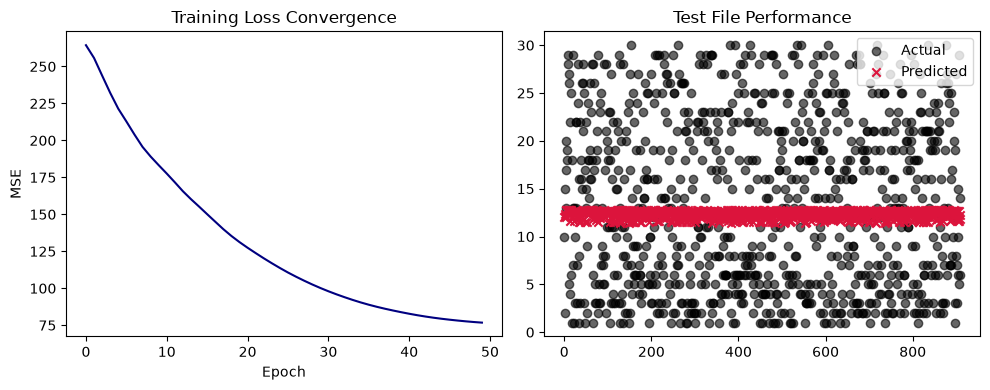

In [17]:
# Plot performance curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='navy')
plt.title("Training Loss Convergence")
plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.subplot(1, 2, 2)
plt.scatter(range(len(y_test)), y_test, label="Actual", color='black', alpha=0.6)
plt.scatter(range(len(test_predictions)), test_predictions, label="Predicted", color='crimson', marker='x')
plt.title("Test File Performance")
plt.legend()
plt.tight_layout()
plt.show()